In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch

In [3]:
# V[t] = V[t-1] + dt/tau_m * (-V[t-1] + R_m*I[t])
# if V[t] >= V_threshold:
#     neuron fires a spike and V[t] is reset to V_reset

# define all the constants
R_m = 5.1      # Membrane resistance in MΩ
C_m = 5e-3      # Membrane capacitance in pF
time_step = 1e-3  # Time step in ms

V_threshold = 1 # Threshold potential for firing a spike in mV


In [4]:
# neuron function (no reset)
def integrate_and_fire(V_prev, time_step, I, R, C):

    tau = R*C
    V = V_prev + (time_step/tau) * (-V_prev + R*I)

    # fire
    if V >= V_threshold:
        spk_out = 1
    else:
        spk_out = 0

    return spk_out, V

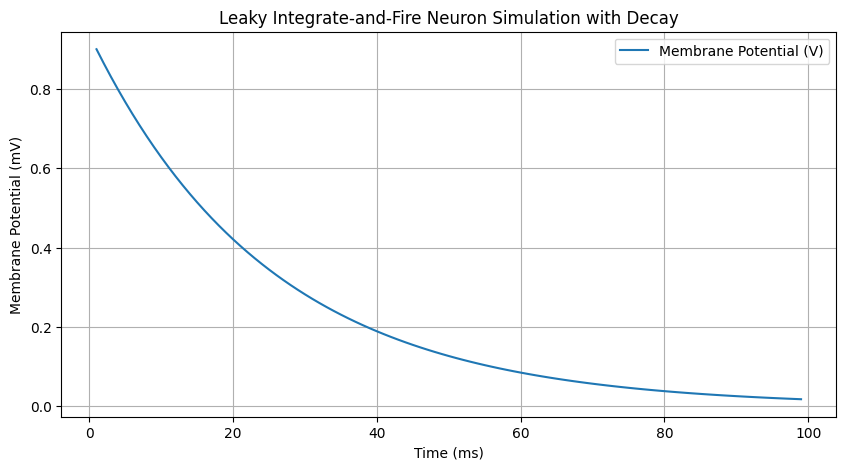

In [5]:
# simulate decay
time = np.arange(0, 100, 1)

I = np.zeros_like(time)  # init input current (no input)
V = 0.9 # init membrane potential

V_trace = []

for t in range(1, len(time)):
    V_trace.append(V)

    spk_out, V = integrate_and_fire(V, time_step=time_step, I=0, R=R_m, C=C_m)

plt.figure(figsize=(10, 5))
plt.plot(time[1:], V_trace, label='Membrane Potential (V)')
plt.title('Leaky Integrate-and-Fire Neuron Simulation with Decay')
plt.xlabel('Time (ms)')
plt.ylabel('Membrane Potential (mV)')
plt.legend()
plt.grid()
plt.show()


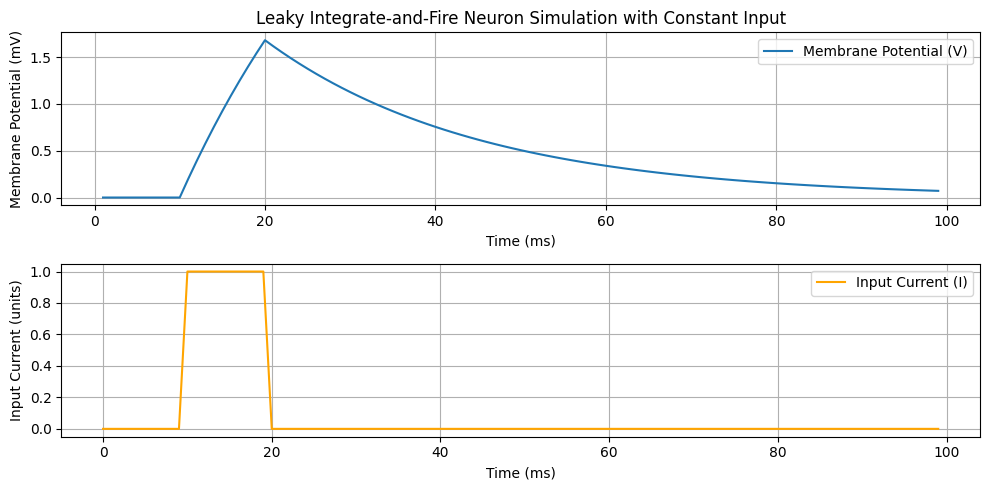

In [6]:
# simulate membrane potential with constant input
time = np.arange(0, 100, 1)
I = np.zeros_like(time)
I[10:20] = 1.0

V = 0
V_trace = []
for t in range(1, len(time)):
    V_trace.append(V)

    _, V = integrate_and_fire(V, time_step=time_step, I=I[t], R=R_m, C=C_m)


# plot
plt.figure(figsize=(10, 5))
plt.subplot(2, 1, 1)
plt.plot(time[1:], V_trace, label='Membrane Potential (V)')
plt.title('Leaky Integrate-and-Fire Neuron Simulation with Constant Input')
plt.xlabel('Time (ms)')
plt.ylabel('Membrane Potential (mV)')
plt.legend()
plt.grid()

plt.subplot(2, 1, 2)
plt.plot(time, I, label='Input Current (I)', color='orange')
plt.xlabel('Time (ms)')
plt.ylabel('Input Current (units)')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


Shape of mem_rec: 200
Shape of spk_rec: 200
Shape of time: 200
Shape of I: 200


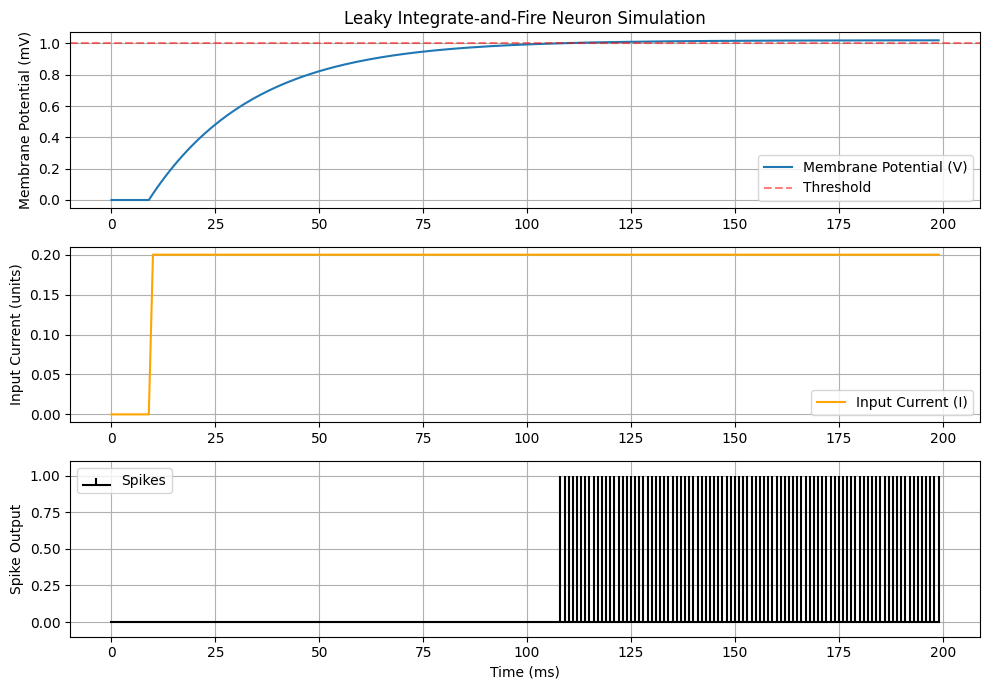

In [7]:
# simulate neuron firing with constant input
time = np.arange(0, 200, 1)
I = torch.cat((torch.zeros(10), torch.ones(190)*0.2), 0)  # Shape: (100,)
mem = 0.0
spk_out = 0.0
mem_rec = [mem]
spk_rec = [spk_out]

for t in range(1, len(time)):
    spk_out, mem = integrate_and_fire(mem, time_step=time_step, I=I[t].item(), R=R_m, C=C_m)
    mem_rec.append(mem)
    spk_rec.append(spk_out)

# print shapes of memrec, spkrec, time, and I
print(f"Shape of mem_rec: {len(mem_rec)}")
print(f"Shape of spk_rec: {len(spk_rec)}")
print(f"Shape of time: {len(time)}")
print(f"Shape of I: {len(I)}")

# plot
plt.figure(figsize=(10, 7))

plt.subplot(3, 1, 1)
plt.plot(time[:], mem_rec, label='Membrane Potential (V)')
plt.axhline(y=V_threshold, color='r', linestyle='--', alpha=0.5, label='Threshold')
plt.title('Leaky Integrate-and-Fire Neuron Simulation')
plt.ylabel('Membrane Potential (mV)')
plt.legend()
plt.grid()

plt.subplot(3, 1, 2)
plt.plot(time, I, label='Input Current (I)', color='orange')
plt.ylabel('Input Current (units)')
plt.legend()
plt.grid()

plt.subplot(3, 1, 3)
#plt.plot(time[:], spk_rec, 'r', linewidth=2, label='Spikes')
plt.stem(time[:], spk_rec, linefmt='k-', markerfmt=' ', basefmt='k-', label='Spikes')
plt.ylabel('Spike Output')
plt.xlabel('Time (ms)')
plt.ylim([-0.1, 1.1])
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()




In [8]:
# neuron function with reset mechanism (substraction)
def reset_integrate_and_fire(V_prev, time_step, I, R, C):

    tau = R*C

    # fire
    if V_prev >= V_threshold:
        spk_out = 1
    else:
        spk_out = 0

    V = V_prev + (time_step/tau) * (-V_prev + R*I) - spk_out * V_threshold


    return spk_out, V

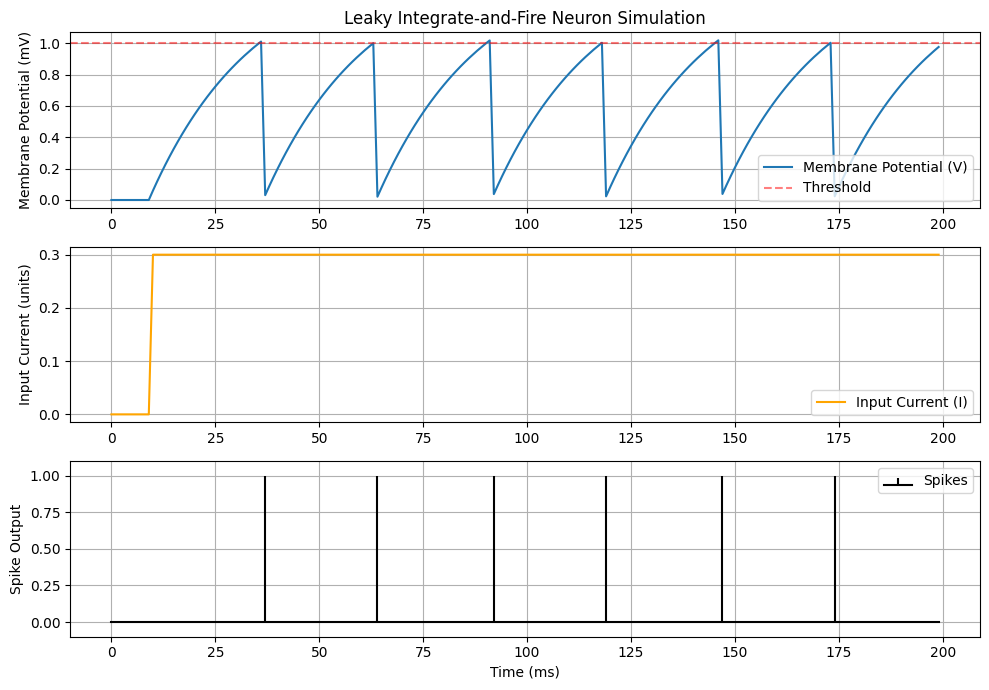

In [9]:
# sim fire and reset
time = np.arange(0, 200, 1)
I = torch.cat((torch.zeros(10), torch.ones(190)*0.3), 0)

mem = 0.0
spk_out = 0.0
mem_rec = [mem]
spk_rec = [spk_out]

for t in range(1, len(time)):
    spk_out, mem = reset_integrate_and_fire(mem, time_step=time_step, I=I[t].item(), R=R_m, C=C_m)
    mem_rec.append(mem)
    spk_rec.append(spk_out)


# plot
plt.figure(figsize=(10, 7))

plt.subplot(3, 1, 1)
plt.plot(time[:], mem_rec, label='Membrane Potential (V)')
plt.axhline(y=V_threshold, color='r', linestyle='--', alpha=0.5, label='Threshold')
plt.title('Leaky Integrate-and-Fire Neuron Simulation')
plt.ylabel('Membrane Potential (mV)')
plt.legend()
plt.grid()

plt.subplot(3, 1, 2)
plt.plot(time, I, label='Input Current (I)', color='orange')
plt.ylabel('Input Current (units)')
plt.legend()
plt.grid()

plt.subplot(3, 1, 3)
#plt.plot(time[:], spk_rec, 'r', linewidth=2, label='Spikes')
plt.stem(time[:], spk_rec, linefmt='k-', markerfmt=' ', basefmt='k-', label='Spikes')
plt.ylabel('Spike Output')
plt.xlabel('Time (ms)')
plt.ylim([-0.1, 1.1])
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()




In [13]:
def gen_spikes(rate_tensor):
    random_vals = torch.rand_like(rate_tensor)
    spikes = (random_vals < rate_tensor).float()
    
    return spikes

In [11]:
num_steps = 200

spk_in = gen_spikes(torch.ones(num_steps)*0.4)  # 50% firing rate

print(f"There are {int(sum(spk_in))} total spikes out of {len(spk_in)} time steps.")


There are 70 total spikes out of 200 time steps.


There are 72 total spikes out of 200 time steps.


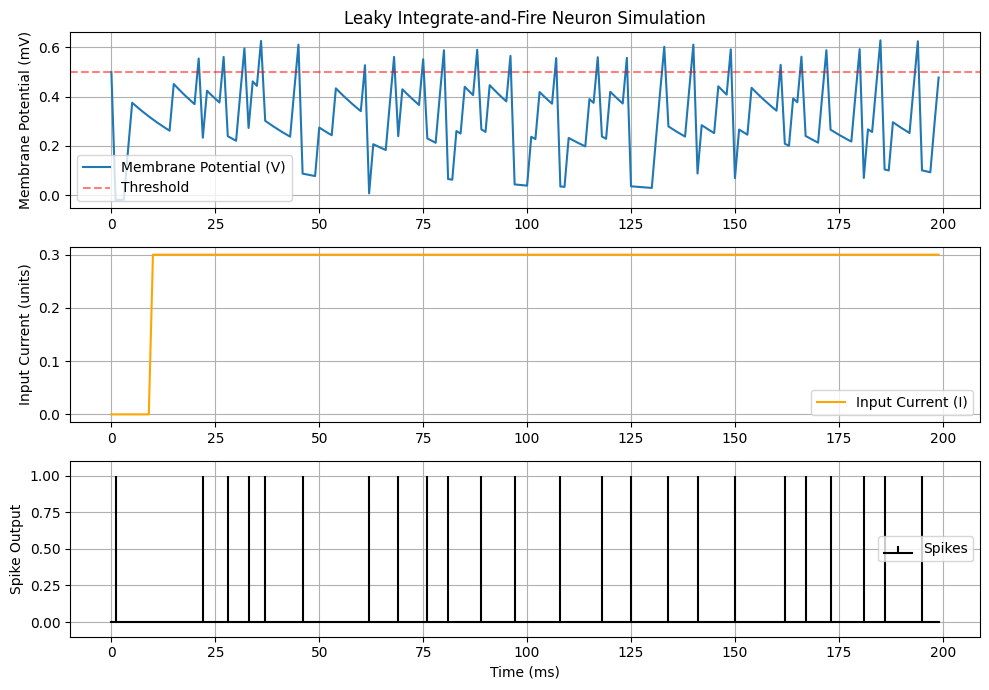

In [12]:
# sim random spikes with reset
time = np.arange(0, 200, 1)
spk_in = gen_spikes(torch.ones(num_steps)*0.4)
print(f"There are {int(sum(spk_in))} total spikes out of {len(spk_in)} time steps.")

V_threshold = 0.5

mem = 0.5
spk_out = 0.0
mem_rec = [mem]
spk_rec = [spk_out]

for t in range(1, len(time)):
    spk_out, mem = reset_integrate_and_fire(mem, time_step=time_step, I=spk_in[t].item(), R=R_m, C=C_m)
    mem_rec.append(mem)
    spk_rec.append(spk_out)


# plot
plt.figure(figsize=(10, 7))

plt.subplot(3, 1, 1)
plt.plot(time[:], mem_rec, label='Membrane Potential (V)')
plt.axhline(y=V_threshold, color='r', linestyle='--', alpha=0.5, label='Threshold')
plt.title('Leaky Integrate-and-Fire Neuron Simulation')
plt.ylabel('Membrane Potential (mV)')
plt.legend()
plt.grid()

plt.subplot(3, 1, 2)
plt.plot(time, I, label='Input Current (I)', color='orange')
plt.ylabel('Input Current (units)')
plt.legend()
plt.grid()

plt.subplot(3, 1, 3)
#plt.plot(time[:], spk_rec, 'r', linewidth=2, label='Spikes')
plt.stem(time[:], spk_rec, linefmt='k-', markerfmt=' ', basefmt='k-', label='Spikes')
plt.ylabel('Spike Output')
plt.xlabel('Time (ms)')
plt.ylim([-0.1, 1.1])
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()